In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import cv2  # For final quality enhancement
from tqdm import tqdm

# --- CONFIG ---
IMG_H, IMG_W = 64, 256
INPUT_DIM = IMG_H * IMG_W 
LATENT_DIM = 128  # Increased for complex words
NUM_WORDS = 10
SAMPLES_PER_WORD = 300
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) 
])

# Load and Filter 
full_ds = datasets.ImageFolder(root="merged_final_dataset", transform=transform)
indices = []
counts = {i: 0 for i in range(NUM_WORDS)}
for i, (_, label) in enumerate(full_ds):
    if label < NUM_WORDS and counts[label] < SAMPLES_PER_WORD:
        indices.append(i)
        counts[label] += 1

train_ds = Subset(full_ds, indices)
dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
idx_to_word = {v: k for k, v in full_ds.class_to_idx.items() if v < NUM_WORDS}

In [35]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_WORDS, NUM_WORDS)
        
        self.model = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_WORDS, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 4096),
            nn.BatchNorm1d(4096),
            nn.LeakyReLU(0.2),
            nn.Linear(4096, INPUT_DIM),
            nn.Tanh()
        )

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], 1)
        return self.model(x).view(-1, 1, IMG_H, IMG_W)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_WORDS, NUM_WORDS)
        self.model = nn.Sequential(
            nn.Linear(INPUT_DIM + NUM_WORDS, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        x = torch.cat([img.view(img.size(0), -1), self.label_emb(labels)], 1)
        return self.model(x)

In [37]:
gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

g_opt = optim.Adam(gen.parameters(), lr=0.0001, betas=(0.5, 0.999))
d_opt = optim.Adam(disc.parameters(), lr=0.0004, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Callbacks
scheduler_g = optim.lr_scheduler.ReduceLROnPlateau(g_opt, 'min', factor=0.5, patience=5)
best_g_loss = float('inf')
early_stop_patience = 15
counter = 0

def train_gan(epochs=150):
    global best_g_loss, counter
    for epoch in range(epochs):
        g_loss_run = 0
        for real_imgs, labels in tqdm(dl, desc=f"Epoch {epoch}"):
            batch_sz = real_imgs.size(0)
            real_imgs, labels = real_imgs.to(DEVICE), labels.to(DEVICE)
            
            # --- Train Discriminator (Label Smoothing) ---
            d_opt.zero_grad()
            out_real = disc(real_imgs, labels)
            d_loss_real = criterion(out_real, torch.ones(batch_sz, 1).to(DEVICE) * 0.9)
            
            z = torch.randn(batch_sz, LATENT_DIM).to(DEVICE)
            fake_imgs = gen(z, labels)
            out_fake = disc(fake_imgs.detach(), labels)
            d_loss_fake = criterion(out_fake, torch.zeros(batch_sz, 1).to(DEVICE))
            
            (d_loss_real + d_loss_fake).backward()
            d_opt.step()

            # --- Train Generator ---
            g_opt.zero_grad()
            out_g = disc(fake_imgs, labels)
            g_loss = criterion(out_g, torch.ones(batch_sz, 1).to(DEVICE))
            g_loss.backward()
            g_opt.step()
            g_loss_run += g_loss.item()

        avg_g_loss = g_loss_run / len(dl)
        scheduler_g.step(avg_g_loss)
        
        # Save best model
        if avg_g_loss < best_g_loss:
            best_g_loss = avg_g_loss
            counter = 0
            torch.save(gen.state_dict(), "best_gen_hq.pth")
        else:
            counter += 1
            if counter >= early_stop_patience: break

train_gan(150)

Epoch 19: 100%|██████████| 16/16 [00:21<00:00,  1.32s/it]


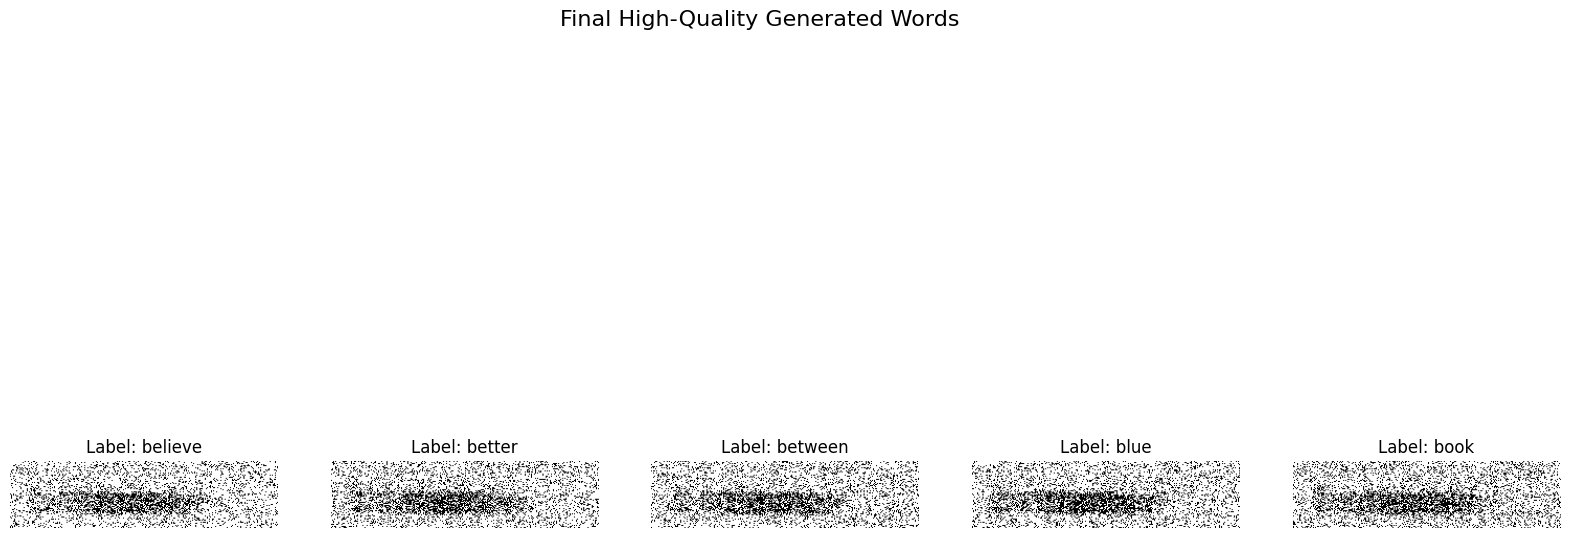

In [38]:
def high_quality_prediction(word_indices=[0, 1, 2, 3, 4]):
    gen.load_state_dict(torch.load("best_gen_hq.pth"))
    gen.eval()
    
    z = torch.randn(len(word_indices), LATENT_DIM).to(DEVICE)
    labels = torch.LongTensor(word_indices).to(DEVICE)
    
    with torch.no_grad():
        imgs = (gen(z, labels).cpu() + 1) / 2
        
    plt.figure(figsize=(20, 10))
    for i in range(len(word_indices)):
        plt.subplot(1, len(word_indices), i+1)
        
        # QUALITY ENHANCEMENT: Otsu Thresholding
        img_8bit = (imgs[i].squeeze().numpy() * 255).astype(np.uint8)
        _, sharp_img = cv2.threshold(img_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        plt.imshow(sharp_img, cmap='gray')
        plt.title(f"Label: {idx_to_word[word_indices[i]]}")
        plt.axis('off')
    plt.suptitle("Final High-Quality Generated Words", fontsize=16)
    plt.show()

high_quality_prediction()